## 6. Caplets and Floorlets: Detailed Theory

$Caplets$ and $Floorlets$ are interest‑rate derivatives written on forward Libor rates. They can both be expressed as options on zero‑coupon bonds.

### 6.1 Forward Rate and Payoff

Let $P(t,T)$ be the price at time $t$ of a zero‑coupon bond maturing at $T$. The forward Libor rate fixed at time $T_1$ for the accrual period $[T_1, T_2]$ is
$$
L(T_1,T_2)
= \frac{1}{T_2 - T_1}\Bigl(\frac{P(T_1,T_1)}{P(T_1,T_2)} - 1\Bigr)
= \frac{1}{T_2 - T_1}\Bigl(\frac{1}{P(T_1,T_2)} - 1\Bigr)\,.
$$

A caplet with notional $N$ and strike $K$ pays at $T_2$:
$$
\mathrm{Payoff}_{\rm caplet}
= N\,(T_2 - T_1)\,\max\bigl(L(T_1,T_2)-K,\,0\bigr)\,.
$$

Define the adjusted strike and notional
$$
K^* = 1 + K\,(T_2 - T_1), 
\qquad
N^* = N\,K^*.
$$

One shows algebraically that
$$
N\,(T_2 - T_1)\,\max(L-K,0)
= N^*\,\max\!\bigl(P(T_1,T_2) - 1/K^*,\,0\bigr)\,.
$$

Likewise, a floorlet payoff is
$$
\mathrm{Payoff}_{\rm floorlet}
= N\,(T_2 - T_1)\,\max(K - L(T_1,T_2),\,0)
= N^*\,\max\!\bigl(\tfrac{1}{K^*} - P(T_1,T_2),\,0\bigr)\,.
$$

### 6.2 Pricing under the $T_2$‑Forward Measure

Under the forward measure $\mathbb{Q}^{T_2}$ (numeraire $P(t,T_2)$), the discounted process 
$$
\frac{P(t,T_1)}{P(t,T_2)}
$$
is a martingale.  Hence the caplet is a European put on the random variable $X = P(T_1,T_2)$:
$$
C_{\rm caplet}
= N^*\,P(0,T_2)\,\mathbb{E}^{T_2}\bigl[\max(X - 1/K^*,\,0)\bigr].
$$
Similarly,
$$
C_{\rm floorlet}
= N^*\,P(0,T_2)\,\mathbb{E}^{T_2}\bigl[\max(1/K^* - X,\,0)\bigr].
$$

### 6.3 Closed‑Form under Hull–White

In the Hull–White one‑factor model, under $\mathbb{Q}^{T_2}$ the bond price has the affine form
$$
X = P(T_1,T_2) = \exp\bigl(A + B\,r(T_1)\bigr),
$$
with
$$
B = \frac{1}{\lambda}\bigl(e^{-\lambda\tau}-1\bigr), 
\quad 
A = \int_{0}^{\tau}\!\lambda\,\theta(\tau - u)\,B(u)\,du 
\;+\;\text{(volatility term)},
$$
where $\tau = T_2 - T_1$.  Let
$$
\mu = E^{T_2}\bigl[r(T_1)\bigr],
\quad
v^2 = \mathrm{Var}^{T_2}\bigl(B\,r(T_1)\bigr).
$$
Then one derives
$$
C_{\rm caplet}
= N^*\,P(0,T_2)\Bigl[\Phi(-d_2)\;-\;\tfrac{1}{K^*}e^{A + B\mu}\,\Phi(-d_1)\Bigr],
$$
$$
C_{\rm floorlet}
= N^*\,P(0,T_2)\Bigl[\tfrac{1}{K^*}e^{A + B\mu}\,\Phi(d_1)\;-\;\Phi(d_2)\Bigr],
$$
with
$$
d_1 = \frac{\ln\!\bigl(K^*e^{-A}\bigr) - B\mu}{v} + \frac{v}{2},
\qquad
d_2 = d_1 - v.
$$

### 6.4 Mapping to Your Code

In your notebook’s `HW_CapletFloorletPrice` you implement exactly:
```python
N_new    = N*(1 + K*(T2 - T1))   # = N^*
K_new    = 1.0/N_new            # = 1/K^*
caplet   = N_new * HW_ZCB_CallPutPrice(OptionType.PUT,    K_new, lambd, eta, P0T, T1, T2)
floorlet = N_new * HW_ZCB_CallPutPrice(OptionType.CALL,   K_new, lambd, eta, P0T, T1, T2)


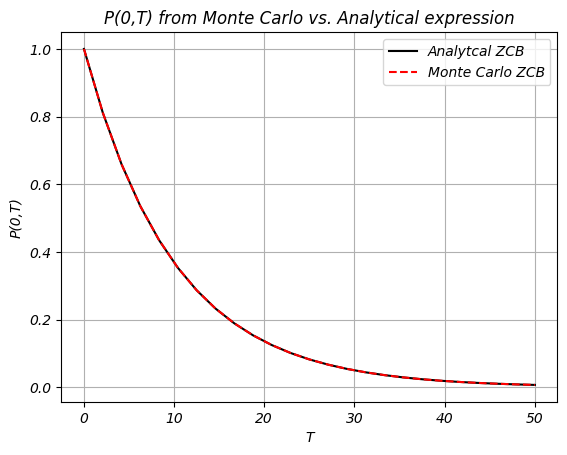

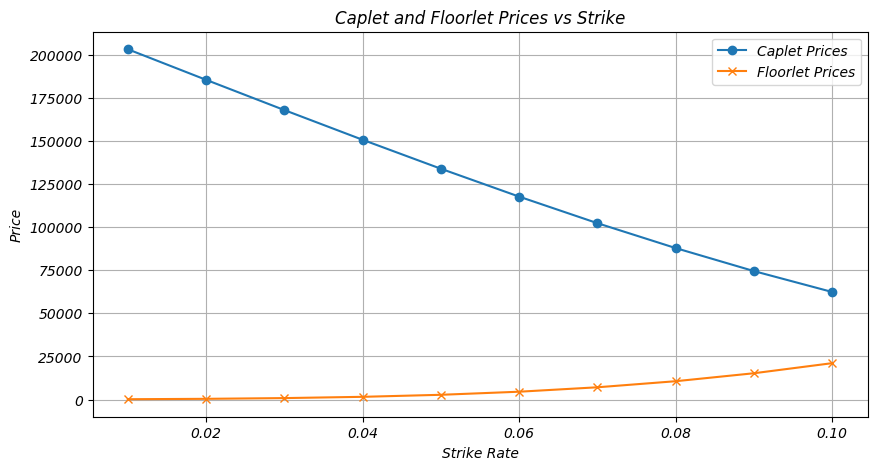

In [1]:
import numpy as np
import enum
import matplotlib.pyplot as plt
import scipy.stats as st
import scipy.integrate as integrate
import scipy.optimize as optimize
from scipy import interpolate


# This class defines puts and calls
class OptionType(enum.Enum):
    CALL = 1.0
    PUT = -1.0


def GeneratePathsHWEuler(NoOfPaths, NoOfSteps, T, P0T, lambd, eta):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)

    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    theta = lambda t: 1.0 / lambd * (f0T(t + dt) - f0T(t - dt)) / (2.0 * dt) + f0T(t) + eta * eta / (
                2.0 * lambd * lambd) * (1.0 - np.exp(-2.0 * lambd * t))

    # theta = lambda t: 0.1 +t -t
    # print("changed theta")

    Z = np.random.normal(0.0, 1.0, [NoOfPaths, NoOfSteps])
    W = np.zeros([NoOfPaths, NoOfSteps + 1])
    R = np.zeros([NoOfPaths, NoOfSteps + 1])
    R[:, 0] = r0
    time = np.zeros([NoOfSteps + 1])

    dt = T / float(NoOfSteps)
    for i in range(0, NoOfSteps):
        # making sure that samples from normal have mean 0 and variance 1
        if NoOfPaths > 1:
            Z[:, i] = (Z[:, i] - np.mean(Z[:, i])) / np.std(Z[:, i])
        W[:, i + 1] = W[:, i] + np.power(dt, 0.5) * Z[:, i]
        R[:, i + 1] = R[:, i] + lambd * (theta(time[i]) - R[:, i]) * dt + eta * (W[:, i + 1] - W[:, i])
        time[i + 1] = time[i] + dt

    # Outputs
    paths = {"time": time, "R": R}
    return paths


def HW_theta(lambd, eta, P0T):
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)
    theta = lambda t: 1.0 / lambd * (f0T(t + dt) - f0T(t - dt)) / (2.0 * dt) + f0T(t) + eta * eta / (
                2.0 * lambd * lambd) * (1.0 - np.exp(-2.0 * lambd * t))
    # print("CHANGED THETA")
    return theta  # lambda t: 0.1+t-t


def HW_A(lambd, eta, P0T, T1, T2):
    tau = T2 - T1
    zGrid = np.linspace(0.0, tau, 250)
    B_r = lambda tau: 1.0 / lambd * (np.exp(-lambd * tau) - 1.0)
    theta = HW_theta(lambd, eta, P0T)
    temp1 = lambd * integrate.trapz(theta(T2 - zGrid) * B_r(zGrid), zGrid)

    temp2 = eta * eta / (4.0 * np.power(lambd, 3.0)) * (
                np.exp(-2.0 * lambd * tau) * (4 * np.exp(lambd * tau) - 1.0) - 3.0) + eta * eta * tau / (
                        2.0 * lambd * lambd)

    return temp1 + temp2


def HW_B(lambd, eta, T1, T2):
    return 1.0 / lambd * (np.exp(-lambd * (T2 - T1)) - 1.0)


def HW_ZCB(lambd, eta, P0T, T1, T2, rT1):
    B_r = HW_B(lambd, eta, T1, T2)
    A_r = HW_A(lambd, eta, P0T, T1, T2)
    return np.exp(A_r + B_r * rT1)


def HWMean_r(P0T, lambd, eta, T):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2.0 * dt)
    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    theta = HW_theta(lambd, eta, P0T)
    zGrid = np.linspace(0.0, T, 2500)
    temp = lambda z: theta(z) * np.exp(-lambd * (T - z))
    r_mean = r0 * np.exp(-lambd * T) + lambd * integrate.trapz(temp(zGrid), zGrid)
    return r_mean


def HW_r_0(P0T, lambd, eta):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)
    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    return r0


def HW_Mu_FrwdMeasure(P0T, lambd, eta, T):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)
    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    theta = HW_theta(lambd, eta, P0T)
    zGrid = np.linspace(0.0, T, 500)

    theta_hat = lambda t, T: theta(t) + eta * eta / lambd * 1.0 / lambd * (np.exp(-lambd * (T - t)) - 1.0)

    temp = lambda z: theta_hat(z, T) * np.exp(-lambd * (T - z))

    r_mean = r0 * np.exp(-lambd * T) + lambd * integrate.trapz(temp(zGrid), zGrid)

    return r_mean


def HWVar_r(lambd, eta, T):
    return eta * eta / (2.0 * lambd) * (1.0 - np.exp(-2.0 * lambd * T))


def HWDensity(P0T, lambd, eta, T):
    r_mean = HWMean_r(P0T, lambd, eta, T)
    r_var = HWVar_r(lambd, eta, T)
    return lambda x: st.norm.pdf(x, r_mean, np.sqrt(r_var))


def HW_CapletFloorletPrice(CP, N, K, lambd, eta, P0T, T1, T2):
    if CP == OptionType.CALL:
        N_new = N * (1.0 + (T2 - T1) * K)
        K_new = 1.0 + (T2 - T1) * K
        caplet = N_new * HW_ZCB_CallPutPrice(OptionType.PUT, 1.0 / K_new, lambd, eta, P0T, T1, T2)
        value = caplet
    elif CP == OptionType.PUT:
        N_new = N * (1.0 + (T2 - T1) * K)
        K_new = 1.0 + (T2 - T1) * K
        floorlet = N_new * HW_ZCB_CallPutPrice(OptionType.CALL, 1.0 / K_new, lambd, eta, P0T, T1, T2)
        value = floorlet
    return value


def HW_ZCB_CallPutPrice(CP, K, lambd, eta, P0T, T1, T2):
    B_r = HW_B(lambd, eta, T1, T2)
    A_r = HW_A(lambd, eta, P0T, T1, T2)

    mu_r = HW_Mu_FrwdMeasure(P0T, lambd, eta, T1)
    v_r = np.sqrt(HWVar_r(lambd, eta, T1))

    K_hat = K * np.exp(-A_r)
    a = (np.log(K_hat) - B_r * mu_r) / (B_r * v_r)

    d1 = a - B_r * v_r
    d2 = d1 + B_r * v_r

    term1 = np.exp(0.5 * B_r * B_r * v_r * v_r + B_r * mu_r) * st.norm.cdf(d1) - K_hat * st.norm.cdf(d2)
    value = P0T(T1) * np.exp(A_r) * term1

    if CP == OptionType.CALL:

        return value
    elif CP == OptionType.PUT:
        return value - P0T(T2) + K * P0T(T1)


def BS_Call_Put_Option_Price(CP, S_0, K, sigma, tau, r):
    if K is list:
        K = np.array(K).reshape([len(K), 1])
    d1 = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma, 2.0)) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    if CP == OptionType.CALL:
        value = st.norm.cdf(d1) * S_0 - st.norm.cdf(d2) * K * np.exp(-r * tau)
    elif CP == OptionType.PUT:
        value = st.norm.cdf(-d2) * K * np.exp(-r * tau) - st.norm.cdf(-d1) * S_0
    return value

def main():
    CP = OptionType.CALL
    NoOfPaths = 20000
    NoOfSteps = 1000

    lambd = 0.02
    eta = 0.02

    P0T = lambda T: np.exp(-0.1 * T)  # np.exp(-0.03*T*T-0.1*T)
    r0 = HW_r_0(P0T, lambd, eta)
    r0 = HW_r_0(P0T, lambd, eta)

    N = 25
    T_end = 50
    Tgrid = np.linspace(0, T_end, N)
    Exact = np.zeros([N, 1])
    Proxy = np.zeros([N, 1])
    for i, Ti in enumerate(Tgrid):
        Proxy[i] = HW_ZCB(lambd, eta, P0T, 0.0, Ti, r0)
        Exact[i] = P0T(Ti)
    plt.figure(1)
    plt.grid()
    plt.plot(Tgrid, Exact, '-k')
    plt.plot(Tgrid, Proxy, '--r')
    plt.legend(["Analytcal ZCB", "Monte Carlo ZCB"])
    plt.title('P(0,T) from Monte Carlo vs. Analytical expression')
    plt.xlabel('T')
    plt.ylabel('P(0,T)')
    plt.show()
    T1, T2 = 4.0, 8.0
    N_nominal = 1e6
    K_array = np.linspace(0.01, 0.10, 10)
    caplet_prices = []
    floorlet_prices = []
    for K in K_array:
        caplet_prices.append(
            HW_CapletFloorletPrice(OptionType.CALL, N_nominal, K, lambd, eta, P0T, T1, T2)
        )
        floorlet_prices.append(
            HW_CapletFloorletPrice(OptionType.PUT, N_nominal, K, lambd, eta, P0T, T1, T2)
        )

    plt.figure(figsize=(10, 5))
    plt.plot(K_array, caplet_prices, marker='o', label='Caplet Prices')
    plt.plot(K_array, floorlet_prices, marker='x', label='Floorlet Prices')
    plt.legend()
    plt.title('Caplet and Floorlet Prices vs Strike')
    plt.xlabel('Strike Rate')
    plt.ylabel('Price')
    plt.grid()
    plt.show()
if __name__ == '__main__':
    main()